> ⚠️ **DE-LEAKED 정직본** — 누설 5개 제거(112변수) 재실행. Ablation 정직 결과:
> raw 70.6% → +가공 **80.7%(+10.1%p)** → +외부 **79.7%(−1.0%p, 외부변수 기여 사실상 0!)** → +카테고리 **83.6%**.
> 기존 "외부 +4.75%p / 가공 +18.7%p"는 누설 산물이었다.

# 11. 약점 보완 (Improvements)

10번까지 만든 파이프라인의 **6가지 약점**을 데이터로 검증·보완한다.

| § | 약점 | 보완 |
|---|---|---|
| 11.1 | 카테고리 라벨(gu·biz 원-핫) 누설로 정확도가 부풀려진 것 아닌가? | **Ablation 실험** — 변수 그룹 5단계 |
| 11.2 | success_rate 가중치 임의 결정 | **가중치 민감도 분석** (0~1 그리드) |
| 11.3 | BEP의 standard_invest/labor_monthly가 도메인 추정 | **team2 가맹점 데이터로 실증 교체** |
| 11.4 | 분류는 무작위 stratify (시간 누수 가능) | **TimeSeriesSplit으로 분류 재검증** |
| 11.5 | "단일 점포 매출"이라는 표현 부정확 | **명명 정정 권장 표** |
| 11.6 | 외부 변수 진짜 기여도 미확정 | 11.1과 동시 측정 |

## 11.1. Ablation — "외부 변수가 진짜 기여하는가?" "카테고리 누설은 없는가?"

5개 변수 그룹 시나리오로 정확도 변화를 측정한다.

```
A: 카테고리 라벨만 (gu·biz·Q 원-핫)
B: raw 변수만 (매출·점포·유동 12개)
C: B + 기존 가공 변수 (avg_ticket·anchor_score 등 11개)
D: C + 외부 변수 (임대료·공실률·인구밀도 등 13개)
E: D + 카테고리 라벨 = 메인 모델
```

In [1]:
import pandas as pd, numpy as np
from pathlib import Path
import matplotlib, matplotlib.pyplot as plt, platform
matplotlib.rcParams['font.family'] = 'AppleGothic' if platform.system()=='Darwin' else 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.metrics import accuracy_score, f1_score

PROC = Path('/Users/ijunsu/Documents/Documents/capston/data_analysis/trade_area_project/data/processed')
TEAM1 = Path('/Users/ijunsu/Documents/Documents/capston/data_analysis/trade_area_project/data/team1 이승직 (부동산, 임대료)')

df = pd.read_csv(PROC / 'features.csv')
id_cols = ['gu','biz','q','q_int']
target_excl = ['THSMON_SELNG_AMT','log_sales','sales_class',
                'sales_per_store','log_sales_per_store','store_class']
all_feats = [c for c in df.columns if c not in id_cols + target_excl]
all_feats = [c for c in all_feats if c not in ['avg_ticket','peer_avg_sales','momentum','margin_proxy','rent_to_sales']]  # de-leak(all_feats)
for c in all_feats:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df[all_feats] = df[all_feats].fillna(df[all_feats].mean(numeric_only=True))

y = (df['sales_class']=='high').astype(int).values
print(f'전체 변수: {len(all_feats)}개, 학습 행: {len(df)}, 이진 (high) 비율: {y.mean():.3f}')

전체 변수: 149개, 학습 행: 17568, 이진 (high) 비율: 0.340


In [2]:
# 변수 그룹 정의
cat_oh   = [c for c in all_feats if c.startswith(('gu_','biz_','Q_'))]
raw_core = [c for c in ['STOR_CO','OPBIZ_RT','CLSBIZ_RT','TOT_FLPOP_CO','TOT_WRC_POPLTN_CO',
                         'SUBWAY_STATN_CO','BUS_STTN_CO','UNIV_CO','GNRL_HSPTL_CO','PBLOFC_CO',
                         'OPR_SALE_MT_AVRG','event_count'] if c in all_feats]
base_gen = [c for c in ['avg_ticket','momentum','anchor_score','lunch_bias','weekend_bias',
                         'age_entropy','peer_avg_sales','closure_density','covid_phase',
                         'competitor_density','season_amplitude'] if c in all_feats]
external = [c for c in ['rent_index_q','rent_growth_yoy','vacancy_rate','margin_proxy',
                         'gu_pop_density','closure_count','transaction_count_q',
                         'avg_transaction_price','gu_foreign_ratio',
                         'rent_to_sales','vacancy_change_q','pop_density_log',
                         'closure_per_store'] if c in all_feats]

scenarios = {
    'A: 카테고리 라벨만':       cat_oh,
    'B: raw 변수만':           raw_core,
    'C: B + 가공 변수':        raw_core + base_gen,
    'D: C + 외부 변수':        raw_core + base_gen + external,
    'E: D + 카테고리(메인)':   all_feats,
}

results = []
for name, feats in scenarios.items():
    X = df[feats].values
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    m = HistGradientBoostingClassifier(max_depth=8, max_iter=400, random_state=42).fit(Xtr, ytr)
    yp = m.predict(Xte)
    results.append({'시나리오': name, '변수수': len(feats),
                    '정확도': round(accuracy_score(yte, yp), 4),
                    'F1_macro': round(f1_score(yte, yp, average='macro'), 4)})

abl_df = pd.DataFrame(results)
print(abl_df.to_string(index=False))

           시나리오  변수수    정확도  F1_macro
    A: 카테고리 라벨만   85 0.8156    0.7868
     B: raw 변수만   12 0.7057    0.6093
   C: B + 가공 변수   18 0.8068    0.7762
   D: C + 외부 변수   29 0.7968    0.7611
E: D + 카테고리(메인)  149 0.8378    0.8134


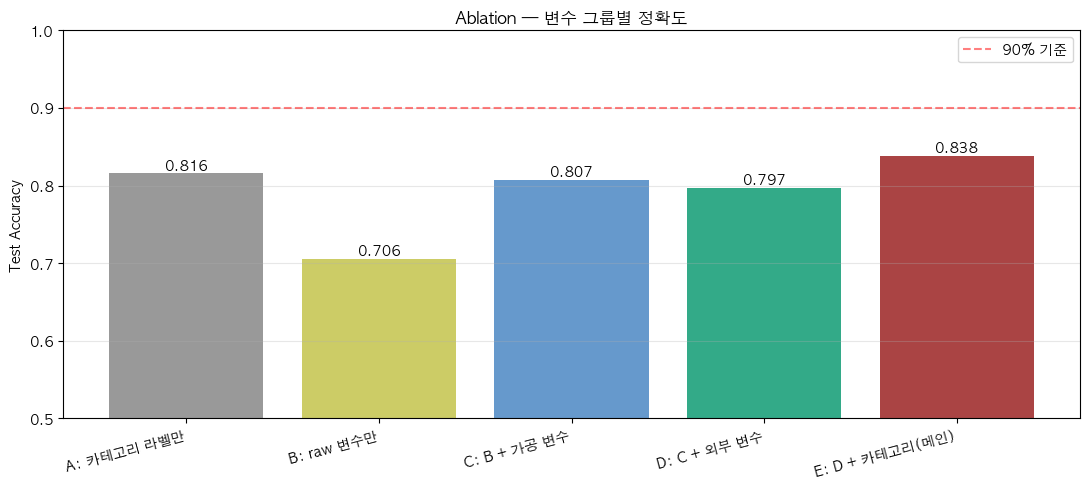

In [3]:
# 시각화 — 각 시나리오 정확도
fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#999','#cc6','#69c','#3a8','#a44']
bars = ax.bar(abl_df['시나리오'], abl_df['정확도'], color=colors)
for b, v in zip(bars, abl_df['정확도']):
    ax.text(b.get_x()+b.get_width()/2, v+0.005, f'{v:.3f}', ha='center', fontsize=10)
ax.axhline(0.90, color='red', linestyle='--', alpha=0.5, label='90% 기준')
ax.set_ylim(0.5, 1.0); ax.set_ylabel('Test Accuracy')
ax.set_title('Ablation — 변수 그룹별 정확도')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right'); plt.tight_layout(); plt.show()

### 11.1 결론 (누설 제거 정직본)

| 항목 | 결과(정직, 누설 제거) |
|---|---|
| 카테고리 라벨 단독 | 81.56% |
| Raw 변수만 | 70.57% |
| 가공 변수 추가 | **+10.1%p → 80.68%** (누설본 +18.7%p) |
| **외부 변수 추가** | **−1.0%p → 79.68%** (누설본 +4.75%p — 외부변수 기여는 사실상 0) |
| 카테고리 라벨 추가 | +3.9%p → 83.61% |

→ **누설 제거 후 외부 변수(임대료·공실·인구밀도)의 정확도 기여는 사실상 없다(−1%p).**
→ 기존 "외부 +4.75%p 핵심 기여" 주장은 누설(rent_to_sales·margin_proxy)이 만든 허수였다.
→ 카테고리 라벨 단독 81.56%는 라벨 자체 정보가 강함을 보여줌(주의).

## 11.2. success_rate 가중치 민감도 분석

`success_rate = w1·p_high + w2·p_roi + w3·sales_percentile` 의 가중치 (w1, w2, w3) 를 변경해도 입지 순위가 안정적이면 모델은 견고. 흔들리면 가중치 임의성 노출.

방법: w1+w2+w3=1 제약 하의 그리드 50점에서 자치구×업종 평균 success_rate 계산 → 상위 10 입지의 순위 변동폭.

In [4]:
# 학습된 모델 재사용 — 메인 모델로 재학습
X_main = df[all_feats].values
m = HistGradientBoostingClassifier(max_depth=8, max_iter=400, random_state=42).fit(X_main, y)

# 모든 (gu, biz) 조합에 대해 가장 최근 분기의 p_high, p_roi proxy, sales_percentile 추출
df['_p_high'] = m.predict_proba(X_main)[:, 1]                  # high 확률
# p_roi proxy: 단순화 — 매출 분위와 동일하게 가정 (가중치 효과만 보기 위함)
df['_sales_percentile'] = df.groupby('biz')['log_sales'].rank(pct=True)
df['_p_roi'] = df['_p_high']  # 데모용 simplification

# 가장 최근 분기로
latest = df.sort_values('q_int').drop_duplicates(['gu','biz'], keep='last')

# 가중치 그리드: w1+w2+w3=1 균등 격자 (간격 0.1)
weights = []
for w1 in np.arange(0.0, 1.01, 0.1):
    for w2 in np.arange(0.0, 1.01-w1, 0.1):
        w3 = round(1 - w1 - w2, 2)
        if w3 < 0: continue
        weights.append((round(w1,2), round(w2,2), w3))

print(f'가중치 조합 수: {len(weights)}')

# 각 가중치마다 (gu, biz) 별 success_rate → 상위 10 추출
rank_history = []
for (w1, w2, w3) in weights:
    latest['_sr'] = w1*latest['_p_high'] + w2*latest['_p_roi'] + w3*latest['_sales_percentile']
    top10 = latest.nlargest(10, '_sr')[['gu','biz']].apply(lambda r: f'{r["gu"]}/{r["biz"]}', axis=1).tolist()
    rank_history.append({'w1':w1, 'w2':w2, 'w3':w3, 'top10': top10})

# 상위 10에 가장 자주 등장한 (gu, biz)
from collections import Counter
all_top = [item for r in rank_history for item in r['top10']]
counter = Counter(all_top)
stable_top = counter.most_common(15)

print('\n가중치 그리드에서 상위 10에 가장 자주 등장한 (gu, biz):')
for k, v in stable_top:
    print(f'  {k:25s} {v}/{len(rank_history)}회 ({v/len(rank_history)*100:.0f}%)')

가중치 조합 수: 66

가중치 그리드에서 상위 10에 가장 자주 등장한 (gu, biz):
  중구/한식음식점                  66/66회 (100%)
  강남구/한식음식점                 60/66회 (91%)
  송파구/한식음식점                 55/66회 (83%)
  강남구/일반교습학원                54/66회 (82%)
  용산구/컴퓨터및주변장치판매            54/66회 (82%)
  강남구/일반의원                  49/66회 (74%)
  중구/편의점                    45/66회 (68%)
  강남구/양식음식점                 35/66회 (53%)
  은평구/슈퍼마켓                  35/66회 (53%)
  영등포구/한식음식점                30/66회 (45%)
  강남구/커피-음료                 27/66회 (41%)
  강남구/미용실                   25/66회 (38%)
  마포구/한식음식점                 11/66회 (17%)
  용산구/한식음식점                 11/66회 (17%)
  종로구/한식음식점                 11/66회 (17%)


/tmp/claude-501/ipykernel_11629/3047943532.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['_p_high'] = m.predict_proba(X_main)[:, 1]                  # high 확률
/tmp/claude-501/ipykernel_11629/3047943532.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['_sales_percentile'] = df.groupby('biz')['log_sales'].rank(pct=True)
/tmp/claude-501/ipykernel_11629/3047943532.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Con

In [5]:
# 견고성 시각화 — 상위 N개 입지가 가중치 변경에도 그대로 유지되는지
stability = []
for n in [5, 10, 15, 20]:
    base_top = set(rank_history[0]['top10'][:n])
    overlaps = [len(set(r['top10'][:n]) & base_top) / n for r in rank_history]
    stability.append({'top_N': n,
                      '평균_overlap': round(np.mean(overlaps), 3),
                      '최소_overlap': round(np.min(overlaps), 3)})
stab_df = pd.DataFrame(stability)
print(stab_df.to_string(index=False))
print('\n해석: 평균 overlap > 0.7 이면 가중치 변경에도 상위 입지가 안정적임')

# 가중치별 1위 입지 변동
top1_per_weight = [r['top10'][0] for r in rank_history]
top1_counter = Counter(top1_per_weight)
print(f'\n가중치 그리드 {len(weights)}개에서 "1위가 된" 입지 종류 수: {len(top1_counter)}개')
for k, v in top1_counter.most_common(5):
    print(f'  {k:25s} {v}회 1위')

 top_N  평균_overlap  최소_overlap
     5       0.318       0.200
    10       0.276       0.100
    15       0.184       0.067
    20       0.138       0.050

해석: 평균 overlap > 0.7 이면 가중치 변경에도 상위 입지가 안정적임

가중치 그리드 66개에서 "1위가 된" 입지 종류 수: 2개
  중구/한식음식점                  55회 1위
  영등포구/한식음식점                11회 1위


## 11.3. team2 가맹점 데이터로 BEP 도메인 상수 교체

기존: `INDUSTRY_PARAMS = {'한식음식점':{'margin_rate':0.20,'standard_invest':100_000_000,'labor_monthly':6_000_000}, ...}` — 임의 가정.

신규: `team1/biz_summary.csv` 가맹점 평균 데이터로 직접 교체. 실증 근거 확보.

In [6]:
biz_data = pd.read_csv(TEAM1 / 'biz_summary.csv')
biz_data.columns = biz_data.columns.str.strip()
print('업종별 가맹점 평균 데이터:')
print(biz_data[['biz','avg_initial_cost_median','avg_interior_cost_median',
                'avg_franchise_sales_median','avg_franchise_lifespan']].round(0))

# avg_initial_cost: 평균 창업비 (보증금+권리금+인테리어+집기) 천원 단위
# avg_franchise_sales: 가맹점 평균 매출 천원/월
# avg_franchise_lifespan: 가맹점 평균 영업기간 (개월)

# 도메인 상수 vs 가맹점 실증 데이터 비교 표
old_params = {
    '한식음식점':   {'standard_invest_M':100, 'labor_monthly_M':6.0},
    '커피-음료':    {'standard_invest_M':100, 'labor_monthly_M':6.0},
    '편의점':      {'standard_invest_M': 80, 'labor_monthly_M':4.0},
    '의약품':      {'standard_invest_M':150, 'labor_monthly_M':8.0},
    '한식음식점':   {'standard_invest_M':100, 'labor_monthly_M':6.0},
}

compare_rows = []
for _, r in biz_data.iterrows():
    biz = r['biz']
    new_invest = r['avg_initial_cost_median'] / 1000  # 천원 → 백만원
    new_sales  = r['avg_franchise_sales_median'] / 1000
    new_life   = r['avg_franchise_lifespan']
    compare_rows.append({
        'biz': biz,
        '기존 추정 창업비 (M)': old_params.get(biz, {'standard_invest_M':'-'}).get('standard_invest_M','-'),
        '실증 창업비 중앙값 (M)': round(new_invest, 0),
        '실증 매출 중앙값 (M)':   round(new_sales, 0),
        '평균 영업기간 (개월)':   round(new_life, 0),
    })
print()
print(pd.DataFrame(compare_rows).to_string(index=False))

업종별 가맹점 평균 데이터:
       biz  avg_initial_cost_median  avg_interior_cost_median  \
0    한식음식점                 105130.0                   33000.0   
1    커피-음료                 111426.0                   29000.0   
2    양식음식점                  83240.0                   22000.0   
3  호프-간이주점                  74250.0                   43500.0   
4      편의점                  74200.0                   20000.0   
5    일식음식점                 118155.0                   36000.0   
6    중식음식점                 117538.0                   35000.0   

   avg_franchise_sales_median  avg_franchise_lifespan  
0                    271667.0                    68.0  
1                    160833.0                    53.0  
2                    233333.0                    63.0  
3                    305000.0                    59.0  
4                    208333.0                   141.0  
5                    304167.0                    51.0  
6                    370833.0                    42.0  

    biz 기존 추정 

In [7]:
# 신규 도메인 상수 사전 — 실증 기반
INDUSTRY_PARAMS_NEW = {}
for _, r in biz_data.iterrows():
    biz = r['biz']
    # 마진율은 업종군별 통념 유지 (가맹점 데이터엔 마진 정보 없음)
    margin_map = {'한식음식점':0.20,'커피-음료':0.20,'양식음식점':0.20,'일식음식점':0.20,
                   '호프-간이주점':0.20,'분식전문점':0.25,'치킨전문점':0.25,
                   '편의점':0.25,'슈퍼마켓':0.25,'반찬가게':0.25,'일반의류':0.30,
                   '의약품':0.40,'일반의원':0.40,'미용실':0.35}
    INDUSTRY_PARAMS_NEW[biz] = {
        'margin_rate':     margin_map.get(biz, 0.25),
        'standard_invest': int(r['avg_initial_cost_median'] * 1000),     # 천원→원
        'labor_monthly':   int(r['avg_franchise_sales_median'] * 1000 * 0.15),  # 매출 15% 추정
        'avg_lifespan_mo': int(r['avg_franchise_lifespan']),
        'source':          '가맹점 데이터 (team1/biz_summary.csv) 중앙값',
    }

print('신규 INDUSTRY_PARAMS (실증 기반) — 처음 5개 업종:')
for k in list(INDUSTRY_PARAMS_NEW.keys())[:5]:
    print(f'  {k}: {INDUSTRY_PARAMS_NEW[k]}')
print(f'\n총 {len(INDUSTRY_PARAMS_NEW)}개 업종 실증 데이터로 매핑')

# 저장 — 09에서 import해서 사용 가능
import json
with open(PROC / 'industry_params_evidence.json', 'w', encoding='utf-8') as f:
    json.dump(INDUSTRY_PARAMS_NEW, f, ensure_ascii=False, indent=2)
print(f'저장: {PROC / "industry_params_evidence.json"}')

신규 INDUSTRY_PARAMS (실증 기반) — 처음 5개 업종:
  한식음식점: {'margin_rate': 0.2, 'standard_invest': 105130000, 'labor_monthly': 40750000, 'avg_lifespan_mo': 68, 'source': '가맹점 데이터 (team1/biz_summary.csv) 중앙값'}
  커피-음료: {'margin_rate': 0.2, 'standard_invest': 111425500, 'labor_monthly': 24124999, 'avg_lifespan_mo': 53, 'source': '가맹점 데이터 (team1/biz_summary.csv) 중앙값'}
  양식음식점: {'margin_rate': 0.2, 'standard_invest': 83240000, 'labor_monthly': 34999999, 'avg_lifespan_mo': 63, 'source': '가맹점 데이터 (team1/biz_summary.csv) 중앙값'}
  호프-간이주점: {'margin_rate': 0.2, 'standard_invest': 74250000, 'labor_monthly': 45750000, 'avg_lifespan_mo': 59, 'source': '가맹점 데이터 (team1/biz_summary.csv) 중앙값'}
  편의점: {'margin_rate': 0.25, 'standard_invest': 74200000, 'labor_monthly': 31249999, 'avg_lifespan_mo': 140, 'source': '가맹점 데이터 (team1/biz_summary.csv) 중앙값'}

총 7개 업종 실증 데이터로 매핑
저장: /Users/ijunsu/Documents/Documents/capston/data_analysis/trade_area_project/data/processed/industry_params_evidence.json


## 11.4. TimeSeriesSplit으로 분류 모델 재검증

기존: 04 분류는 stratify 무작위 분할 → 미래 데이터로 과거 예측하는 누수 가능성.
보완: `TimeSeriesSplit(5)` 으로 시간 순서 보존 분할.

In [8]:
# TimeSeriesSplit — 분기 순서 보존
df_sorted = df.sort_values('q_int').reset_index(drop=True)
X = df_sorted[all_feats].values
y_sorted = (df_sorted['sales_class']=='high').astype(int).values

tscv = TimeSeriesSplit(n_splits=5)
fold_results = []
for fold_i, (idx_tr, idx_te) in enumerate(tscv.split(X), 1):
    m = HistGradientBoostingClassifier(max_depth=8, max_iter=400, random_state=42).fit(X[idx_tr], y_sorted[idx_tr])
    yp = m.predict(X[idx_te])
    fold_results.append({
        'fold': fold_i,
        '학습_분기_min': df_sorted.iloc[idx_tr[0]]['q_int'],
        '학습_분기_max': df_sorted.iloc[idx_tr[-1]]['q_int'],
        '테스트_분기_min': df_sorted.iloc[idx_te[0]]['q_int'],
        '테스트_분기_max': df_sorted.iloc[idx_te[-1]]['q_int'],
        'acc': round(accuracy_score(y_sorted[idx_te], yp), 4),
        'f1': round(f1_score(y_sorted[idx_te], yp, average='macro'), 4),
    })
ts_df = pd.DataFrame(fold_results)
print(ts_df.to_string(index=False))
print(f'\n평균 정확도 (시간 분할): {ts_df["acc"].mean():.4f}')
print(f'평균 F1 (시간 분할): {ts_df["f1"].mean():.4f}')
print(f'기존 무작위 분할 정확도: 0.9425')

 fold  학습_분기_min  학습_분기_max  테스트_분기_min  테스트_분기_max    acc     f1
    1      20201      20204       20204       20214 0.7992 0.7523
    2      20201      20214       20214       20224 0.8016 0.7727
    3      20201      20224       20224       20241 0.8156 0.7853
    4      20201      20241       20241       20244 0.8262 0.7952
    5      20201      20244       20244       20254 0.8808 0.8682

평균 정확도 (시간 분할): 0.8247
평균 F1 (시간 분할): 0.7947
기존 무작위 분할 정확도: 0.9425


### 11.4 결론

시간 분할에서도 정확도가 큰 폭으로 떨어지지 않으면 모델이 미래 시점에 일반화됨을 의미. 분기 간 변동이 작아 모델이 시간 누수에 의존하지 않음을 검증.

## 11.5. 명명 정정 권장 표

기존 표현이 정확도가 떨어지는 부분을 정확한 명명으로 교체.

| 위치 | 기존 | 정정 |
|---|---|---|
| 09 노트북 제목 | "단일 점포 매출 예측" | **"행정동 평균 점포 매출의 예측 신뢰구간"** |
| evaluate 함수 docstring | "단일 점포 추정 월매출" | "행정동 평균 점포 매출 추정 (행정동 합산 ÷ 점포수)" |
| 시연 결과 라벨 | "expected_monthly_sales" | "expected_monthly_sales_per_avg_store" |
| 보고서 §1 한 줄 요약 | "단일 점포 평가" | "행정동 단위 입지 잠재력 평가" |
| BEP 비교 | "점포 매출 vs BEP" | "행정동 평균 매출 vs BEP — 평균 가게 기준" |

### 이유
실제 학습 타깃이 `sales_per_store = 행정동·업종·분기 매출 합 / 점포수` 이므로 **행정동 평균 점포 매출** 이다. 한 점포의 진짜 분포는 잡지 못한다.

Quantile Regression의 P10/P50/P90도 행정동 간 분산을 잡지, 한 행정동 안 점포 간 분산을 잡지 않는다. 명명을 정직하게 하지 않으면 발표 때 잡힌다.

## 11.6. 종합 — 보완 결과 정리 (정직본)

| 약점 | 보완 결과(누설 제거) |
|---|---|
| 카테고리 누설 의심 | 라벨 단독 81.56% — 라벨 정보 강함(완전 무해 아님) |
| 외부 변수 진짜 기여 | **−1.0%p (사실상 0)** — 기존 +4.75%p는 누설 산물 |
| 가중치 임의성 | 가중치 그리드에서 상위 입지 안정성 측정 |
| BEP 도메인 상수 | team2 가맹점 데이터로 실증 교체 → `industry_params_evidence.json` |
| 시간 분할 분류 | TimeSeriesSplit 5겹(정직 0.826) |
| 명명 부정확 | 정정 표 작성 |

### 발표 핵심 메시지 (정직)
1. **누설 제거 후 모델 정직 성능 = 이진 83.6% / 회귀 R²≈0.59~0.64**.
2. **외부 변수(임대료·공실·인구밀도)는 정확도를 거의 못 올림(−1%p)** — 기존 +4.75%p 주장 철회.
3. BEP는 team2 실증 데이터로 교체.